In [1]:
# pip install pyscipopt
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader   
import dwave_networkx as dnx
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import random
from skimage.transform import resize
import pandas as pd
import os
from torchvision import datasets, transforms
import dwave.system
import dimod
from dwave.samplers import SimulatedAnnealingSampler
import json
from pyscipopt import Model, quicksum
import numpy as np
import dimod
import itertools
from pyomo.environ import ConcreteModel, Var, Constraint, Objective, SolverFactory, NonNegativeIntegers, Binary, summation, value, RangeSet
from datetime import datetime

from optihelper import *
from torch.optim.lr_scheduler import ReduceLROnPlateau
from bolmaqua import *
from vizhelper import *
from savehelper import *

In [2]:
K = 3
G = dnx.zephyr_graph(K)
G_contracted = G.copy()  # Placeholder, replace with actual contracted graph from optimization
V_target = 144
H_target = 32

In [3]:
# NODE ASSIGNMENT STRATEGY: MAX-CUT OPTIMIZATION TO MAXIMIZE V-H CROSS-EDGES
def build_and_solve_maxcut(G, K, V_target, H_target, tee=False):
    """
    Simplified optimization: DIRECTLY maximize V-H edges.
    This is the "max-cut" problem on the graph.
    """
    # Build Zephyr graph
    nodes = sorted(G.nodes())
    n = len(nodes)
    node_index = {i: idx for idx, i in enumerate(nodes)}

    edges = sorted(set((min(u, v), max(u, v)) for u, v in G.edges()))
    
    m = Model("MaxCutVH")
    
    # Variables
    x = {i: m.addVar(vtype="B", name=f"x_{i}") for i in nodes}  # 1 = visible
    
    # Edge indicator: y_ij = 1 if edge (i,j) crosses V-H boundary
    y = {}
    for (i, j) in edges:
        y[(i, j)] = m.addVar(vtype="B", name=f"y_{i}_{j}")
    
    # Constraints
    
    # 1. Visible count
    m.addCons(quicksum(x[i] for i in nodes) == V_target, "visible_count")
    
    # 2. Linearize cross-edges: y_ij = |x_i - x_j|
    for (i, j) in edges:
        m.addCons(y[(i, j)] >= x[i] - x[j])
        m.addCons(y[(i, j)] >= x[j] - x[i])
        m.addCons(y[(i, j)] <= x[i] + x[j])
        m.addCons(y[(i, j)] <= 2 - (x[i] + x[j]))
    
    # Objective: MAXIMIZE total V-H cross-edges
    m.setObjective(quicksum(y[(i, j)] for (i, j) in edges), "maximize")
    
    # Solve settings
    m.setParam("limits/time", 60)
    m.setParam("limits/gap", 0.1)
    
    print(f"Solving max-cut for K={K}, V={V_target}")
    m.optimize()
    
    sol = m.getBestSol()
    if sol is None:
        print("No solution found!")
        return None
    
    x_vals = {i: m.getSolVal(sol, x[i]) for i in nodes}
    
    visible_nodes = [i for i in nodes if x_vals[i] > 0.5]
    hidden_nodes = [i for i in nodes if x_vals[i] <= 0.5]
    
    # Count actual cross-edges
    cross_edges = sum(1 for (i, j) in edges if (i in visible_nodes) != (j in hidden_nodes))
    total_edges = len(edges)
    
    print(f"✓ Solution found:")
    print(f"  Visible: {len(visible_nodes)}, Hidden: {len(hidden_nodes)}")
    print(f"  Cross-edges: {cross_edges} / {total_edges} ({100*cross_edges/total_edges:.1f}%)")
    
    return {
        "x": x_vals,
        "visible_nodes": visible_nodes,
        "hidden_nodes": hidden_nodes,
        "cross_edges": cross_edges,
        "G": G
    }

In [4]:

# NODE ASSIGNMENT STRATEGY: ALTERNATING LAYERS BASED ON ZEHPYR LAYOUT
# Rebuild original graph for training (or use G_contracted if you want to train on fused graph)
def assign_alternating_layers(G, V_target):
    """
    Assign visible/hidden based on position in Zephyr layout.
    Exploits spatial locality.
    """
    pos = dnx.zephyr_layout(G)
    nodes = sorted(G.nodes())
    
    # Project nodes onto 1D axis (e.g., x-coordinate)
    x_coords = {n: pos[n][0] for n in nodes}
    
    # Sort by x-coordinate
    sorted_nodes = sorted(nodes, key=lambda n: x_coords[n])
    
    # Alternating assignment: V, H, V, H, ...
    visible = []
    hidden = []
    
    for i, node in enumerate(sorted_nodes):
        if len(visible) < V_target:
            if i % 2 == 0:  # Even positions
                visible.append(node)
            else:
                hidden.append(node)
        else:
            hidden.append(node)
    
    # Adjust if needed
    while len(visible) < V_target:
        visible.append(hidden.pop())
    
    while len(visible) > V_target:
        hidden.append(visible.pop())
    
    return visible, hidden

In [5]:
# NODE ASSIGNMENT STRATEGY: CHECKERBOARD BASED ON 2D POSITION
def assign_checkerboard(G, V_target):
    """
    Assign nodes in checkerboard pattern based on 2D position.
    Similar to bipartite graphs.
    """
    pos = dnx.zephyr_layout(G)
    nodes = sorted(G.nodes())
    
    # Assign based on (x + y) % 2
    visible = []
    hidden = []
    
    for node in nodes:
        x, y = pos[node]
        # Discretize coordinates
        x_bin = int(x * 10)  # Scale for granularity
        y_bin = int(y * 10)
        
        if (x_bin + y_bin) % 2 == 0:
            if len(visible) < V_target:
                visible.append(node)
            else:
                hidden.append(node)
        else:
            if len(hidden) < len(nodes) - V_target:
                hidden.append(node)
            else:
                visible.append(node)
    
    return visible, hidden

In [6]:
# NODE ASSIGNMENT STRATEGY: HIGH-DEGREE NODES TO VISIBLE, BALANCED ACROSS GRAPH
def assign_by_degree_balanced(G, V_target):
    """
    Assign high-degree nodes to visible, but balance across graph.
    Ensures good mixing.
    """
    pos = dnx.zephyr_layout(G)
    degrees = dict(G.degree())
    nodes = sorted(G.nodes())
    
    # Score nodes by: degree * centrality
    center = np.mean([pos[n] for n in nodes], axis=0)
    scores = {}
    for node in nodes:
        deg = degrees[node]
        dist = np.linalg.norm(np.array(pos[node]) - center)
        # High degree + central = high score
        scores[node] = deg / (1 + dist)
    
    # Top scorers become visible
    sorted_nodes = sorted(nodes, key=lambda n: -scores[n])
    visible = sorted_nodes[:V_target]
    hidden = sorted_nodes[V_target:]
    
    return visible, hidden

In [7]:
def evaluate_assignment(G, visible, hidden):
    """
    Evaluate quality of a V/H assignment.
    """
    visible_set = set(visible)
    hidden_set = set(hidden)
    
    vv = sum(1 for u, v in G.edges() if u in visible_set and v in visible_set)
    hh = sum(1 for u, v in G.edges() if u in hidden_set and v in hidden_set)
    vh = sum(1 for u, v in G.edges() if (u in visible_set) != (v in visible_set))
    
    total = vv + hh + vh
    
    print(f"  V-V edges: {vv} ({100*vv/total:.1f}%)")
    print(f"  H-H edges: {hh} ({100*hh/total:.1f}%)")
    print(f"  V-H edges: {vh} ({100*vh/total:.1f}%) ← MAXIMIZE THIS")
    print(f"  Quality score: {vh / total:.3f}")
    
    return vh / total


print("Alternating Layers:")
v1, h1 = assign_alternating_layers(G, V_target)
score1 = evaluate_assignment(G, v1, h1)

print("\nCheckerboard:")
v2, h2 = assign_checkerboard(G, V_target)
score2 = evaluate_assignment(G, v2, h2)

print("\nDegree-Based:")
v3, h3 = assign_by_degree_balanced(G, V_target)
score3 = evaluate_assignment(G, v3, h3)

print(f"\n→ Best heuristic: {['Alternating', 'Checkerboard', 'Degree'][np.argmax([score1, score2, score3])]}")

Alternating Layers:
  V-V edges: 614 (21.9%)
  H-H edges: 946 (33.7%)
  V-H edges: 1248 (44.4%) ← MAXIMIZE THIS
  Quality score: 0.444

Checkerboard:
  V-V edges: 495 (17.6%)
  H-H edges: 857 (30.5%)
  V-H edges: 1456 (51.9%) ← MAXIMIZE THIS
  Quality score: 0.519

Degree-Based:
  V-V edges: 1080 (38.5%)
  H-H edges: 1072 (38.2%)
  V-H edges: 656 (23.4%) ← MAXIMIZE THIS
  Quality score: 0.234

→ Best heuristic: Checkerboard


In [8]:
def solve_with_guaranteed_counts(K, V_target, H_target):
    """
    Phase 1: Get visible assignment (any method)
    Phase 2: Reduce hidden count by fusion (always works!)
    """
    G = dnx.zephyr_graph(K)
    n = G.number_of_nodes()
    
    print(f"Target: {V_target} visible, {H_target} hidden (total {V_target + H_target})")
    print(f"Available: {n} nodes")
    print(f"Need to remove: {n - V_target - H_target} nodes")
    
    # Phase 1: Assign visible (use best heuristic or optimization)
    # Try optimization first, fall back to heuristic
    try:
        result = build_and_solve_maxcut(K, V_target, H_target, tee=False)
        if result and len(result['visible_nodes']) == V_target:
            visible = result['visible_nodes']
            hidden = result['hidden_nodes']
            print("✓ Optimization succeeded")
        else:
            raise Exception("Optimization failed, using heuristic")
    except:
        print("⚠ Optimization failed, using degree-based heuristic")
        visible, hidden = assign_by_degree_balanced(G, V_target)
    
    # Phase 2: Reduce hidden count by greedy fusion
    print(f"\nPhase 2: Reducing {len(hidden)} hidden → {H_target}")
    
    G_work = G.copy()
    hidden_remaining = set(hidden)
    visible_set = set(visible)
    
    while len(hidden_remaining) > H_target:
        # Find lowest-degree hidden node
        degrees = [(n, G_work.degree(n)) for n in hidden_remaining]
        degrees.sort(key=lambda x: x[1])
        
        node1 = degrees[0][0]
        
        # Find hidden neighbor
        hidden_neighbors = [nb for nb in G_work.neighbors(node1) 
                           if nb in hidden_remaining and nb != node1]
        
        if not hidden_neighbors:
            # Isolated - just remove
            G_work.remove_node(node1)
            hidden_remaining.discard(node1)
            continue
        
        node2 = min(hidden_neighbors, key=lambda n: G_work.degree(n))
        
        # Fuse
        G_work = nx.contracted_nodes(G_work, node1, node2, self_loops=False)
        hidden_remaining.discard(node2)
    
    print(f"✓ Final counts: {len(visible)} visible, {len(hidden_remaining)} hidden")
    
    return G_work, visible, list(hidden_remaining)

Target: 144 visible, 32 hidden (total 176)
Available: 336 nodes
Need to remove: 160 nodes
⚠ Optimization failed, using degree-based heuristic

Phase 2: Reducing 192 hidden → 32
✓ Final counts: 144 visible, 32 hidden

Final result:
  Visible: 144 (target: 144)
  Hidden: 32 (target: 32)


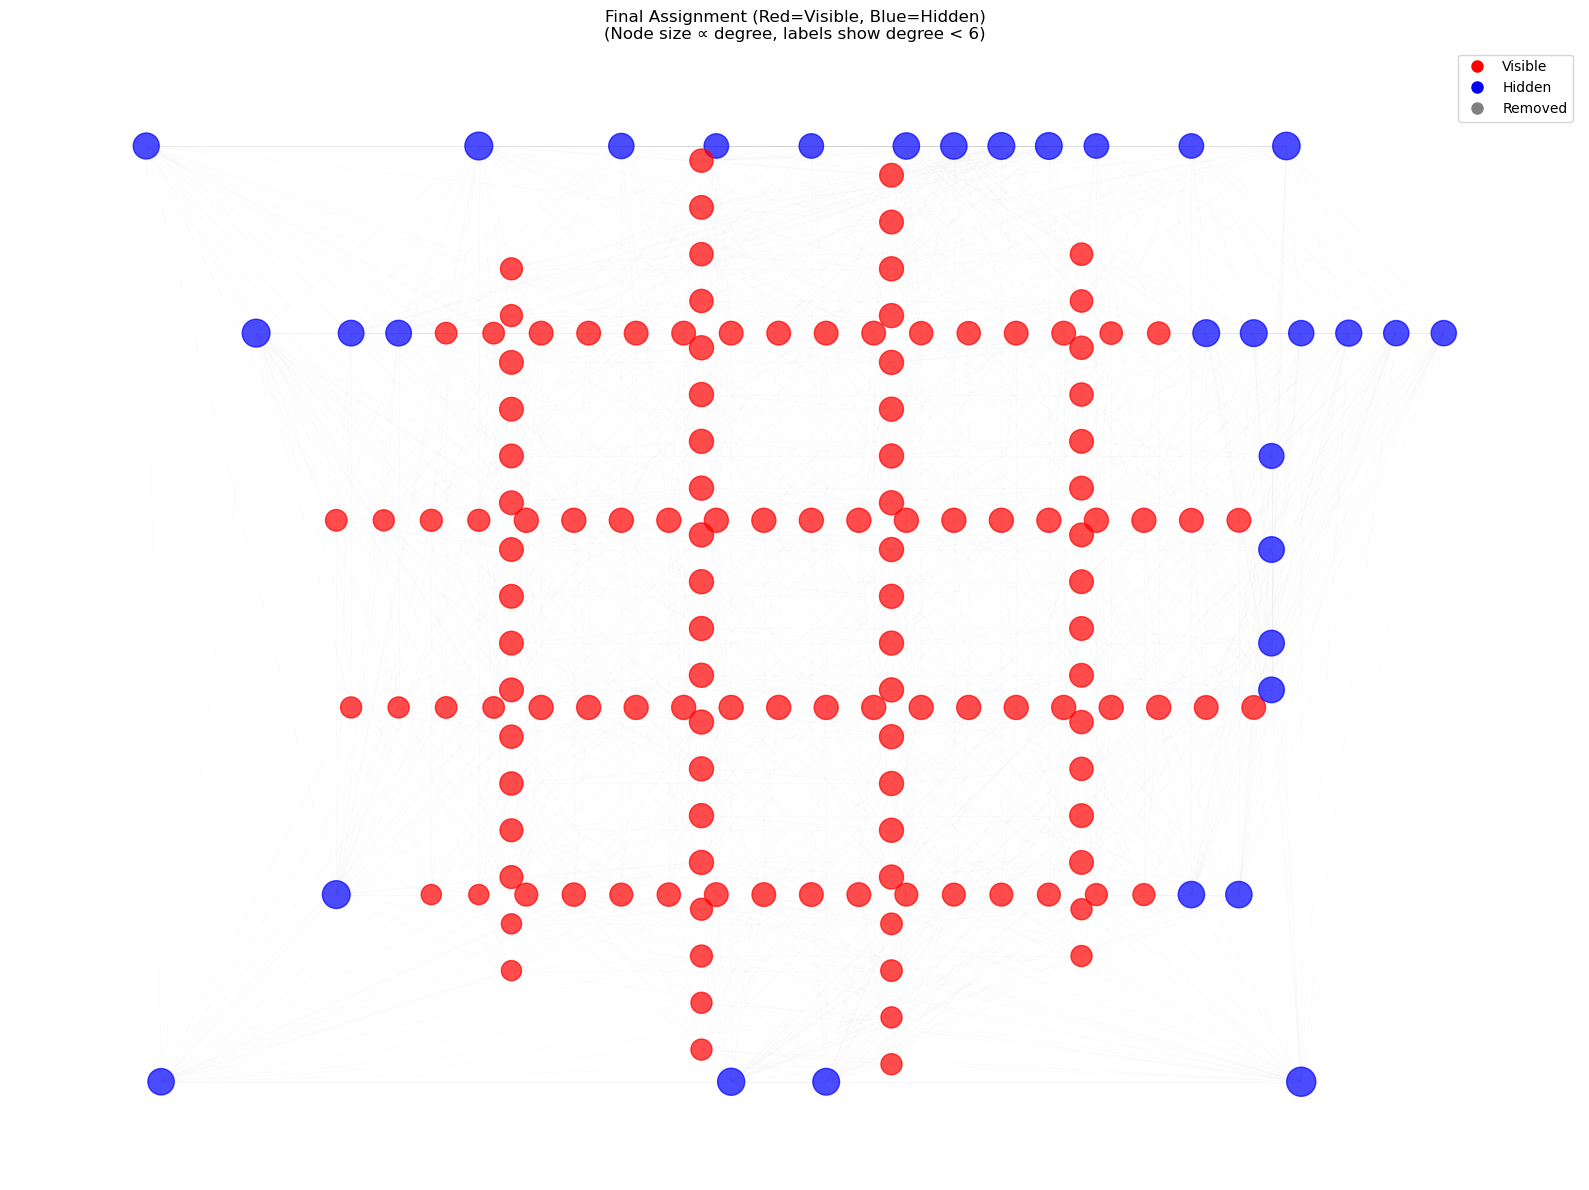

In [9]:
# visible_nodes, hidden_nodes = assign_checkerboard(G, V_target)
G_contracted, visible_nodes, hidden_nodes = solve_with_guaranteed_counts(K, V_target, H_target)


# Greedy post-processing to reach exact target
# G_contracted, visible_nodes, hidden_nodes = postprocess_fuse_hidden(
#     G, visible_nodes, hidden_nodes, H_target)


print(f"\nFinal result:")
print(f"  Visible: {len(visible_nodes)} (target: 144)")
print(f"  Hidden: {len(hidden_nodes)} (target: 32)")

# G_contracted = G_fused
visualize_node_assignment_on_zephyr(G_contracted, visible_nodes, hidden_nodes, 
                                    title="Final Assignment (Red=Visible, Blue=Hidden)")

In [10]:

print(f"\nAfter fusion:")
print(f"  Contracted nodes: {G_contracted.number_of_nodes()}")
print(f"  Visible: {len(visible_nodes)}")
print(f"  Hidden: {len(hidden_nodes)}")
print(f"  Expected hidden: {H_target}")

# Relabel for training
G, visible_nodes, hidden_nodes, relabel_mapping = relabel_for_training(
    G_contracted, visible_nodes, hidden_nodes
)

print(f"\nRelabeled graph:")
print(f"  Visible node IDs: 0 to {len(visible_nodes)-1}")
print(f"  Hidden node IDs: {len(visible_nodes)} to {len(visible_nodes)+len(hidden_nodes)-1}")

# G = G_contracted

# Create training structures
# Create vh_nodearray (1 for visible, 0 for hidden)
n = G.number_of_nodes()
vh_nodearray = np.zeros(n, dtype=int)

# Mark visible nodes as 1
for v in visible_nodes:
    vh_nodearray[v] = 1

# Create node_labels dictionary
node_labels = {i: ('visible' if vh_nodearray[i] == 1 else 'hidden') 
               for i in range(n)}

# Update global variables
NUM_VISIBLE = len(visible_nodes)
NUM_HIDDEN = len(hidden_nodes)

print(f"\n✓ Ready for training:")
print(f"  Total nodes: {n}")
print(f"  Visible nodes: {NUM_VISIBLE}")
print(f"  Hidden nodes: {NUM_HIDDEN}")
print(f"  vh_nodearray shape: {vh_nodearray.shape}")

# Graph with layer info
for v in visible_nodes:
    G.nodes[v]["layer"] = "visible"
for h in hidden_nodes:
    G.nodes[h]["layer"] = "hidden"


After fusion:
  Contracted nodes: 176
  Visible: 144
  Hidden: 32
  Expected hidden: 32
Relabeling complete:
  Old node types: {'int'}
  New node IDs: all integers [0, 175]

Relabeled graph:
  Visible node IDs: 0 to 143
  Hidden node IDs: 144 to 175

✓ Ready for training:
  Total nodes: 176
  Visible nodes: 144
  Hidden nodes: 32
  vh_nodearray shape: (176,)


 Cross-edges (V-H): 436 out of 1705
 Visible nodes: 144
 Hidden nodes: 32


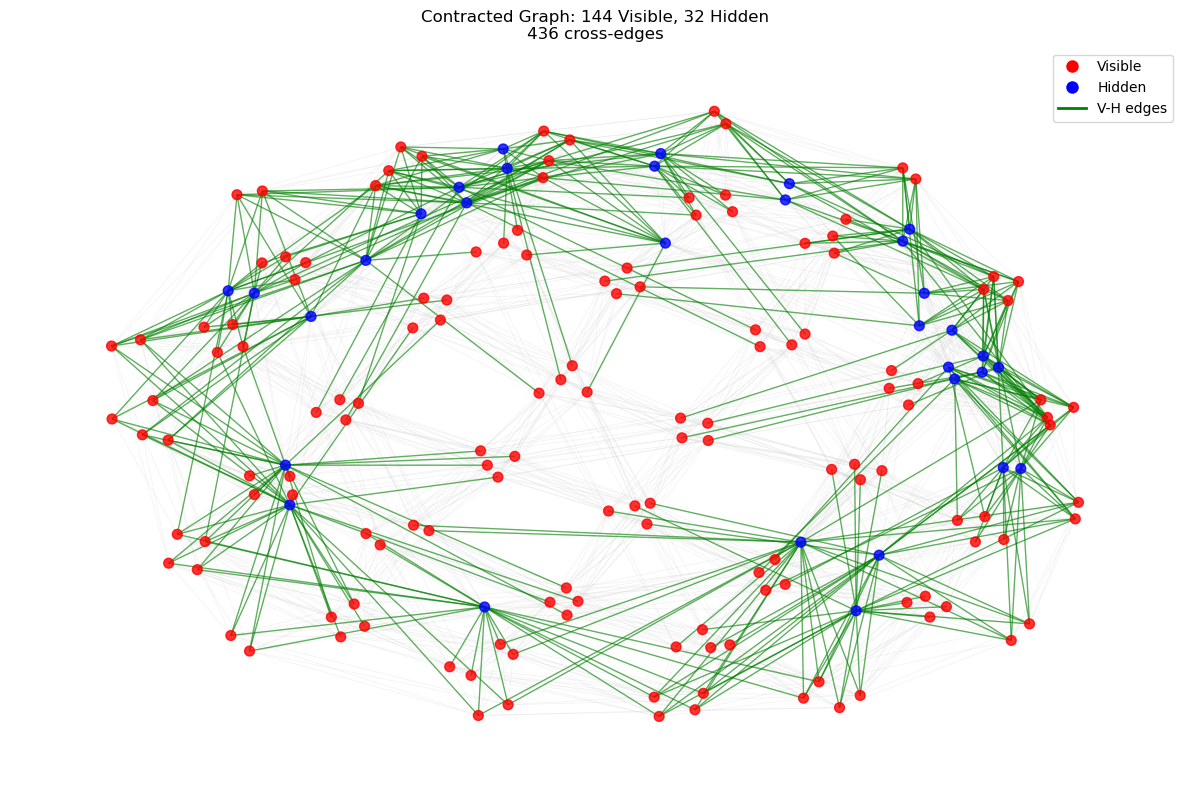

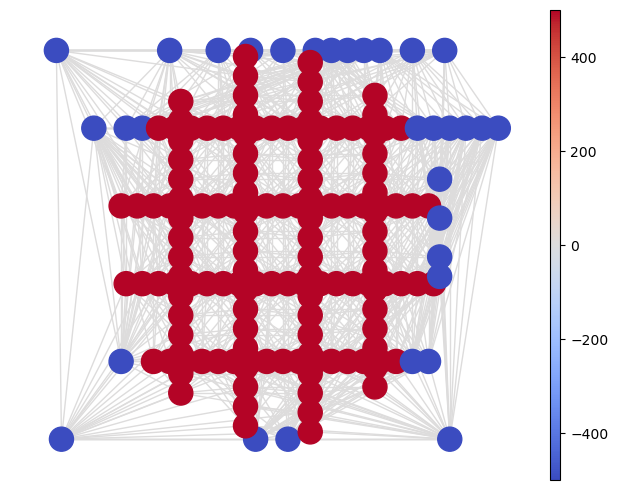

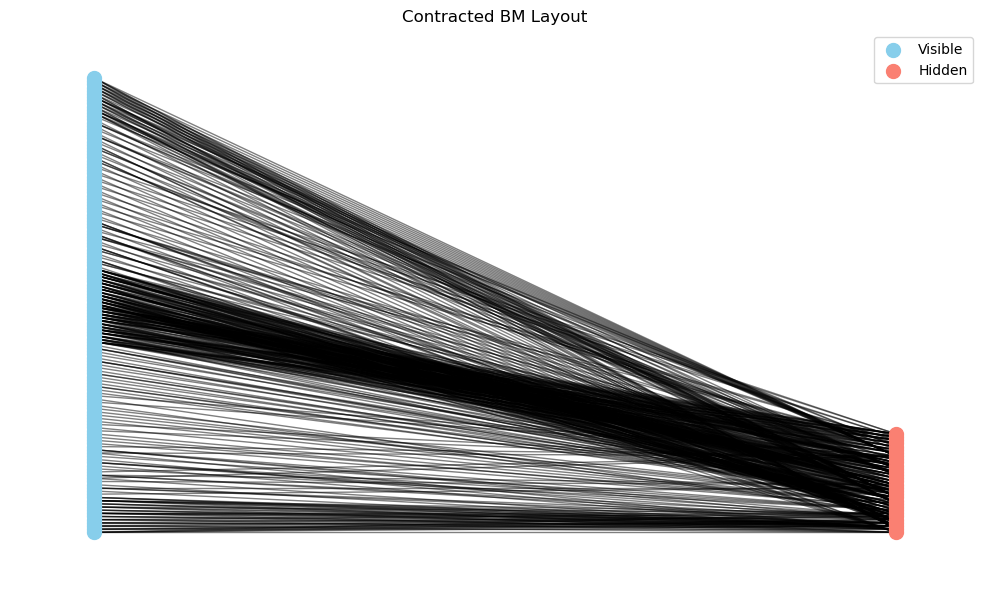

In [11]:

# Visualize the relabeled graph
x_sol = visualize_contracted_graph(G, visible_nodes, hidden_nodes, use_zephyr_layout=False)

# original Zephyr visualization (if it works with contracted graph)
try:
    draw_zephyr_hidden_visible(G, vh_nodearray)
except Exception as e:
    print(f" Zephyr visualization doesn't work on contracted graph: {e}")


# Use the bipartite layout from bolmaqua.py
visualize_bm_bipartite_layout(G, node_labels, title="Contracted BM Layout")

Loading dataset...
Found existing .\mnist12x12_trainfeats.npy and .\mnist12x12_trainlabels.npy.
Found existing .\mnist12x12_testfeats.npy and .\mnist12x12_testlabels.npy.
After flattening, X_data shape: torch.Size([12665, 144])


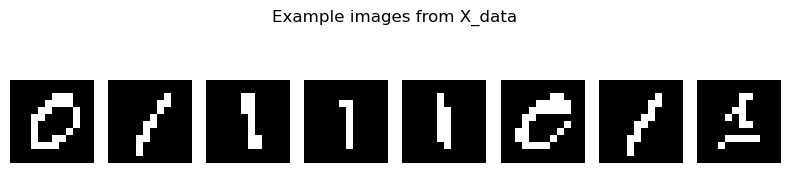

In [12]:

# --- Dataset Loading ---
print("Loading dataset...")
try:
    mnist_feats, mnist_labels = generate_downsized_mnist_torchvision(output_dir=".", grid_shape=GRID_SHAPE)
except FileNotFoundError as e:
    print("Error: Could not find MNIST CSVs. Falling back to synthetic data...")
    mnist_feats = np.random.rand(1000, NUM_VISIBLE) > 0.3
    mnist_feats = mnist_feats.astype(np.float32)
    mnist_labels = np.zeros(len(mnist_feats), dtype=np.float32)


# Only keep images with label 0 or 1
mnist_feats = mnist_feats[(mnist_labels == 0) | (mnist_labels == 1)]
mnist_labels = mnist_labels[(mnist_labels == 0) | (mnist_labels == 1)]


#cut size of dataset massively for faster training
# num_images_to_use = 500
# mnist_feats = mnist_feats[:num_images_to_use]  # Use only the first few images for quick testing
mnist_feats = (mnist_feats - mnist_feats.min()) / (mnist_feats.max() - mnist_feats.min())

# Binarize and create DataLoader
roundup_boost = 0
X_data = (torch.from_numpy(mnist_feats).float() > 0.5 + roundup_boost).float() # default is < 0.5
# Flatten from (N, 13, 13) → (N, 169)
if X_data.ndim == 3:
    X_data = X_data.view(X_data.shape[0], -1)

# Make sure shape is (num_samples, 169)
print("After flattening, X_data shape:", X_data.shape)

# Split into training and validation sets
train_size = int(0.9 * len(X_data))
X_train = X_data[:train_size]
X_val = X_data[train_size:]

# Add labels explicitly, even if dummy, to avoid 1-tuple nesting
train_dataset = torch.utils.data.TensorDataset(X_train, torch.zeros(len(X_train)))
val_dataset = torch.utils.data.TensorDataset(X_val, torch.zeros(len(X_val)))

dataset = torch.utils.data.TensorDataset(X_data, torch.zeros(len(X_data)))

# --- Visualize a few images from X_data ---
plt.figure(figsize=(8, 2))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(X_data[i].cpu().numpy().reshape(GRID_SHAPE), cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
plt.suptitle("Example images from X_data")
plt.tight_layout()
plt.show()

In [13]:
# Create fresh node_labels dictionary
node_labels = {}
for node in G.nodes():
    if node in visible_nodes:
        node_labels[node] = 'visible'
    elif node in hidden_nodes:
        node_labels[node] = 'hidden'
    else:
        print(f"Warning: Node {node} not in visible or hidden lists!")
        node_labels[node] = 'hidden'  # Default to hidden

# Verify all nodes are covered
print(f"\n=== Node Label Check ===")
print(f"  Graph nodes: {G.number_of_nodes()}")
print(f"  Labeled nodes: {len(node_labels)}")
print(f"  Visible labeled: {sum(1 for v in node_labels.values() if v == 'visible')}")
print(f"  Hidden labeled: {sum(1 for v in node_labels.values() if v == 'hidden')}")

if set(G.nodes()) != set(node_labels.keys()):
    missing = set(G.nodes()) - set(node_labels.keys())
    extra = set(node_labels.keys()) - set(G.nodes())
    print(f" Mismatch detected!")
    print(f"    Missing from labels: {missing}")
    print(f"    Extra in labels: {extra}")
    raise ValueError("Graph nodes and node_labels keys don't match!")


=== Node Label Check ===
  Graph nodes: 176
  Labeled nodes: 176
  Visible labeled: 144
  Hidden labeled: 32


In [14]:
def add_local_pixel_connections(G, visible_nodes, grid_shape=(12,12)):
    """
    Add edges between spatially-close visible nodes to respect image structure.
    """
    
    rows, cols = grid_shape
    G_enhanced = G.copy()
    
    # Map visible nodes to pixel positions
    visible_to_pixel = {visible_nodes[i]: (i // cols, i % cols) 
                        for i in range(len(visible_nodes))}
    
    edges_added = 0
    for i, v1 in enumerate(visible_nodes):
        r1, c1 = visible_to_pixel[v1]
        
        # Connect to 4-neighbors in image space
        for dr, dc in [(-1,0), (1,0), (0,-1), (0,1)]:
            r2, c2 = r1 + dr, c1 + dc
            if 0 <= r2 < rows and 0 <= c2 < cols:
                idx2 = r2 * cols + c2
                if idx2 < len(visible_nodes):
                    v2 = visible_nodes[idx2]
                    if not G_enhanced.has_edge(v1, v2):
                        G_enhanced.add_edge(v1, v2)
                        edges_added += 1
    
    print(f"Added {edges_added} local pixel connections")
    return G_enhanced

# Use AFTER getting final graph:
G_with_locality = add_local_pixel_connections(G, visible_nodes, grid_shape)

G = G_with_locality

Added 192 local pixel connections


Graph has 176 nodes and 1897 edges
V-V edges: 1272, H-H edges: 189, V-H edges: 436
V-V edges: 1272, H-H edges: 189, V-H edges: 436
Building Boltzmann Machine from graph... 🏗️
Sanity check:
  model num_visible   : 144
  model num_hidden    : 32
  W_vh shape (should be V x H): (144, 32)
Scheduler created: will reduce LR by 0.5x if no improvement for 5 epochs
Starting PCD training on cpu for 10 epochs... 🏋️


e:\CONDA\envs\PY\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
e:\CODE\BM and QA Local\BM-and-QA-3\bolmaqua.py:263: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\Users\dev-admin\Desktop\build42\libtorch_1738271764196\work\aten\src\ATen\native\TensorShape.cpp:3687.)
  field_vh = h_current @ W_vh[unit_idx, :].T


Epoch 1/10 | PCD: -13.6386 | PLL: -0.2048 | Train Recon: MSE=0.0739 BCE=0.2327 Acc=0.893 | Val Recon: MSE=0.0829 BCE=0.2584 Acc=0.881
Epoch 2/10 | PCD: -7.0876 | PLL: -0.1927 | Train Recon: MSE=0.0844 BCE=0.2653 Acc=0.883 | Val Recon: MSE=0.0902 BCE=0.2838 Acc=0.876
Epoch 3/10 | PCD: -4.6711 | PLL: -0.1948 | Train Recon: MSE=0.0864 BCE=0.2809 Acc=0.884 | Val Recon: MSE=0.0946 BCE=0.3082 Acc=0.873
Epoch 4/10 | PCD: -3.1723 | PLL: -0.1796 | Train Recon: MSE=0.0921 BCE=0.3030 Acc=0.877 | Val Recon: MSE=0.0925 BCE=0.3041 Acc=0.876
Epoch 5/10 | PCD: -2.1361 | PLL: -0.1580 | Train Recon: MSE=0.0979 BCE=0.3328 Acc=0.874 | Val Recon: MSE=0.1033 BCE=0.3510 Acc=0.869
Epoch 6/10 | PCD: -1.5976 | PLL: -0.1239 | Train Recon: MSE=0.0973 BCE=0.3391 Acc=0.877 | Val Recon: MSE=0.0919 BCE=0.3192 Acc=0.881
Epoch 7/10 | PCD: -1.0950 | PLL: -0.1938 | Train Recon: MSE=0.0948 BCE=0.3263 Acc=0.880 | Val Recon: MSE=0.1036 BCE=0.3477 Acc=0.869
Epoch 8/10 | PCD: -1.0085 | PLL: -0.1739 | Train Recon: MSE=0.0939 B

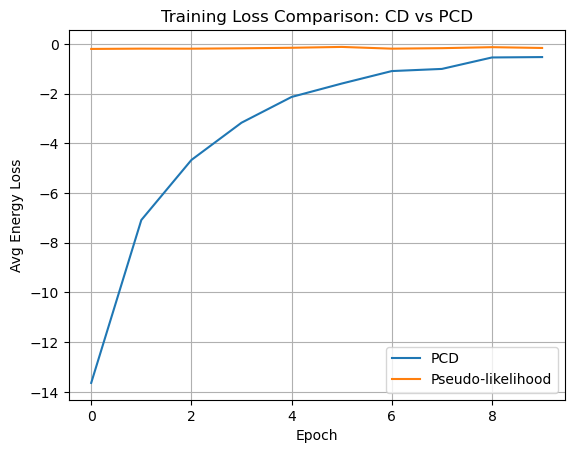

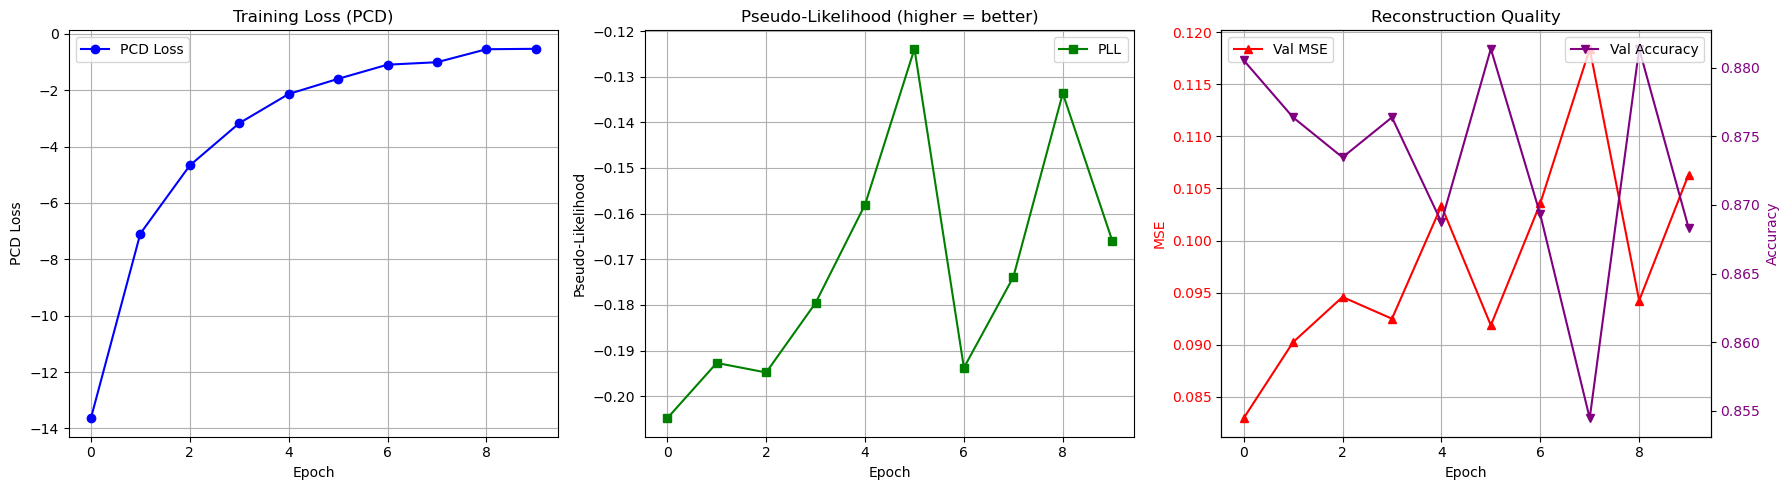

In [15]:
'''Hyperparameters here. 
num_gibbs_steps is an important addition, which determines 
how many gibbs steps are done for each sample in training
Increasing it increases training time linearly, unfortunately, 
and it is quite slow. '''
step_size = 0.005 # You can change this value for experiments 
l2_amount = 1e-4 # L2 regularization amount
num_epochs = 10
batch_size = 20
num_gibbs_steps = 5


data_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)



# # Print some graph statistics
print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
vv_edges = sum(1 for u, v in G.edges() if u < NUM_VISIBLE and v < NUM_VISIBLE)
hh_edges = sum(1 for u, v in G.edges() if u >= NUM_VISIBLE and v >= NUM_VISIBLE)
vh_edges = sum(1 for u, v in G.edges() if (u < NUM_VISIBLE) != (v < NUM_VISIBLE))
print(f"V-V edges: {vv_edges}, H-H edges: {hh_edges}, V-H edges: {vh_edges}")

visible_set = set(visible_nodes)
hidden_set = set(hidden_nodes)

vv_edges = sum(1 for u, v in G.edges() if u in visible_set and v in visible_set)
hh_edges = sum(1 for u, v in G.edges() if u in hidden_set and v in hidden_set)
vh_edges = sum(1 for u, v in G.edges() if (u in visible_set) != (v in visible_set))

print(f"V-V edges: {vv_edges}, H-H edges: {hh_edges}, V-H edges: {vh_edges}")


# visualize_bm_bipartite_layout(G, node_labels, title="My Custom BM Layout (Bipartite Style)")


# Use the factory function
# model_cd = graph_to_bm(G, node_labels)
model_pcd = graph_to_bm(G, node_labels)


# Sanity check
print("Sanity check:")
# print("  dataset feature dim:", X_data.shape[1])
print("  model num_visible   :", model_pcd.num_visible)
print("  model num_hidden    :", model_pcd.num_hidden)

# optional: ensure W_vh orientation (V x H)
W_vv, W_hh, W_vh = model_pcd._get_masked_weights()
W_vv.zero_() # disables v-v connections
print("  W_vh shape (should be V x H):", tuple(W_vh.shape))
assert W_vh.shape == (model_pcd.num_visible, model_pcd.num_hidden)

# Pre-training visible
# pretrain_visible_biases(model_pcd, data_loader, epochs=10, lr=0.001)

# --- Training ---
optimizer_pcd = torch.optim.Adam(model_pcd.parameters(), lr=step_size, betas=(0.9, 0.999), eps=1e-8, weight_decay=l2_amount) # betas and eps added

# Trying to Add scheduler:
scheduler = ReduceLROnPlateau(
    optimizer_pcd, 
    mode='max',           # We want to maximize PLL (less negative = better)
    factor=0.5,           # Reduce LR by half when plateauing
    patience=5,           # Wait 5 epochs before reducing
    verbose=True,         # Print when LR changes
    min_lr=1e-5          # Don't go below this
)

print(f"Scheduler created: will reduce LR by 0.5x if no improvement for 5 epochs")

results = train_boltzmann_machine_pcd(model_pcd, data_loader, optimizer_pcd, num_epochs=num_epochs, k_steps=num_gibbs_steps, 
                                        batch_size=batch_size, step_size=step_size, scheduler=scheduler, val_data= X_val, train_data = X_train, persistent=True)

# Unpack results:
pcd_losses = results['pcd_loss']
pll_values = results['pll']
train_mse = results['train_recon_mse']
train_bce = results['train_recon_bce']
train_acc = results['train_recon_acc']
val_mse = results['val_recon_mse']
val_bce = results['val_recon_bce']
val_acc = results['val_recon_acc']


# --------------------------------------------------------------------------------------------
# Training Visualization
# check_fusion_strength(model_pcd, fused_pairs_remapped)
# --- Plot training loss ---
plt.plot(pcd_losses, label='PCD')
plt.plot(pll_values, label="Pseudo-likelihood")
plt.xlabel('Epoch')
plt.ylabel('Avg Energy Loss')
plt.title('Training Loss Comparison: CD vs PCD')
plt.legend()
plt.grid(True)
plt.show()


# Replace your plotting code with:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: PCD Loss
axes[0].plot(pcd_losses, label='PCD Loss', marker='o', color='blue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('PCD Loss')
axes[0].set_title('Training Loss (PCD)')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Pseudo-Likelihood
axes[1].plot(pll_values, label='PLL', marker='s', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Pseudo-Likelihood')
axes[1].set_title('Pseudo-Likelihood (higher = better)')
axes[1].legend()
axes[1].grid(True)

# Plot 3: Reconstruction Metrics
if val_mse is not None:
    ax3a = axes[2]
    ax3b = ax3a.twinx()
    
    ax3a.plot(val_mse, label='Val MSE', marker='^', color='red')
    ax3b.plot(val_acc, label='Val Accuracy', marker='v', color='purple')
    
    ax3a.set_xlabel('Epoch')
    ax3a.set_ylabel('MSE', color='red')
    ax3b.set_ylabel('Accuracy', color='purple')
    ax3a.set_title('Reconstruction Quality')
    ax3a.tick_params(axis='y', labelcolor='red')
    ax3b.tick_params(axis='y', labelcolor='purple')
    ax3a.legend(loc='upper left')
    ax3b.legend(loc='upper right')
    ax3a.grid(True)
else:
    axes[2].text(0.5, 0.5, 'No reconstruction data', ha='center', va='center')
    axes[2].set_title('Reconstruction (not tracked)')

plt.tight_layout()
plt.show()

Running Gibbs sampler for 5 samples, 2000 burn-in steps each... 🔥
  Gibbs sample 1/5
  Gibbs sample 2/5
  Gibbs sample 3/5
  Gibbs sample 4/5
  Gibbs sample 5/5
Gibbs sampling complete.

Displaying generated images... 🖼️


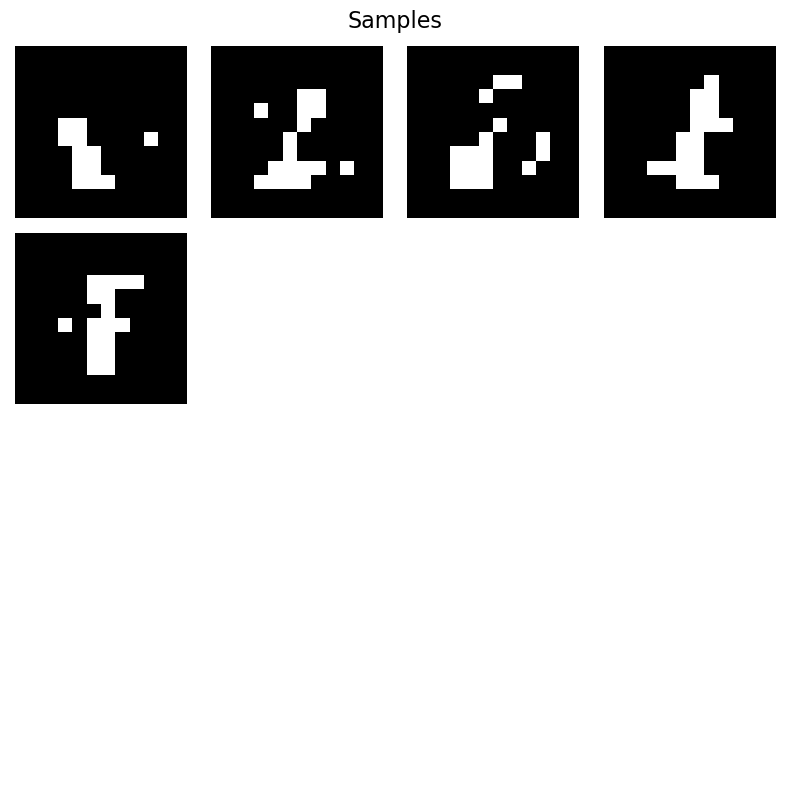

In [25]:
#--- Sampling & Visualization ---
num_gen_samples = 5
burn_in = 2000


#need to find a way to speed up these sampling functions, so slow
samples_pcd = sample_from_bm(model_pcd, num_gen_samples, burn_in, method='gibbs')


def plot_samples(samples: torch.Tensor, title: str):
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        if i < samples.shape[0]:
            ax.imshow(samples[i].cpu().numpy().reshape(GRID_SHAPE), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

print("\nDisplaying generated images... 🖼️")
plot_samples(samples_pcd, "Samples")

In [ ]:
print("\n--- Improving samples with Tabu Search ---")
tabu_steps = 7
tabu_improved_samples = []
for i in range(samples_pcd.shape[0]):
    v_init = samples_pcd[i].unsqueeze(0)
    improved_v = tabu_search_bm(model_pcd, v_init, steps=tabu_steps)
    tabu_improved_samples.append(improved_v)
tabu_improved_samples = torch.stack(tabu_improved_samples, dim=0)

print("\nDisplaying Tabu Search improved images... 🖼️")
plot_samples(tabu_improved_samples, f"Tabu Search Improved Samples ({tabu_steps} steps)")